<a href="https://colab.research.google.com/github/marcusslongweek/Homework/blob/main/CS4410HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt
import numpy as np

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

X.shape, y.shape

((150, 4), (150,))

In [3]:
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)
    k_scores.append(scores.mean())

In [4]:
for k, score in zip(k_range, k_scores):
    print(f"k={k}: {score:.4f}")

k=1: 0.9600
k=2: 0.9533
k=3: 0.9667
k=4: 0.9667
k=5: 0.9667
k=6: 0.9667
k=7: 0.9667
k=8: 0.9667
k=9: 0.9733
k=10: 0.9667
k=11: 0.9667
k=12: 0.9733
k=13: 0.9800
k=14: 0.9733
k=15: 0.9733
k=16: 0.9733
k=17: 0.9733
k=18: 0.9800
k=19: 0.9733
k=20: 0.9800
k=21: 0.9667
k=22: 0.9667
k=23: 0.9733
k=24: 0.9600
k=25: 0.9667
k=26: 0.9600
k=27: 0.9667
k=28: 0.9533
k=29: 0.9533
k=30: 0.9533


In [5]:
best_score = max(k_scores)
best_k = list(k_range)[k_scores.index(best_score)]

print("Best k:", best_k)
print("Best cross-validated accuracy:", best_score)

Best k: 13
Best cross-validated accuracy: 0.9800000000000001


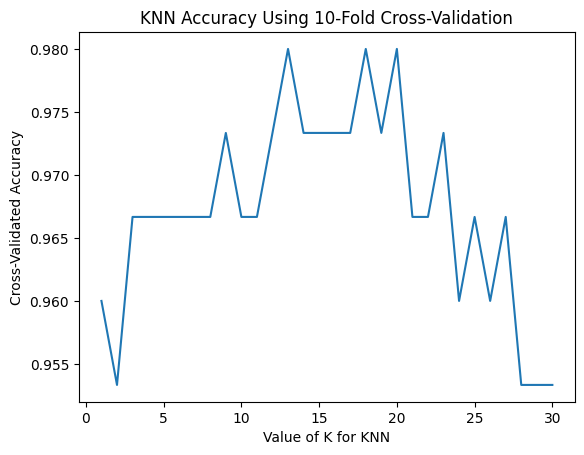

In [6]:
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Accuracy Using 10-Fold Cross-Validation')
plt.show()

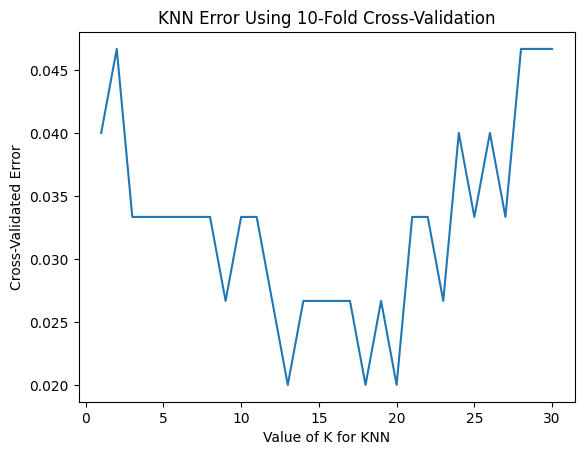

In [7]:
k_errors = [1 - score for score in k_scores]

plt.plot(k_range, k_errors)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Error')
plt.title('KNN Error Using 10-Fold Cross-Validation')
plt.show()

In [8]:
param_grid = {'n_neighbors': range(1, 31)}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=10,
    scoring='accuracy'
)

grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best accuracy:", grid.best_score_)

Best parameters: {'n_neighbors': 13}
Best accuracy: 0.9800000000000001
